# E-Commerce Recommendation System Pipeline
### Implementing and Comparing Machine Learning Algorithms for Rating Prediction, Purchase Likelihood, and Customer Segmentation

This notebook contains the complete implementation of the machine learning tasks for our E-Commerce recommendation system project:
- **Part A: Regression** to predict product ratings using Linear Regression and Ridge Regression.
- **Part B: Classification** to predict whether a customer will purchase a product using Logistic Regression.
- **Part C: Clustering** to group customers based on shopping behavior using K-Means.
- **Part D: Hyperparameter Optimization** to find the best configuration for the models.
- **Part E: Model Evaluation and Business Alignment** to compare the performance and map them to business goals.

## Step 1: Data Collection & Preprocessing
We load the dataset and perform preprocessing (encoding categorical variables and scaling numerical features).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load dataset
df = pd.read_csv('../data/ecommerce_dataset.csv')
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (30, 14)


,User_ID,Product_ID,Category,Price,Rating,Browsing_Time,Previous_Purchases,Cart_Addition,Purchase_Status,Age,Gender,Location,Discount_Applied,Total_Spending
0,U001,P101,Electronics,799,5,18.5,7,1,1,28,Male,Hyderabad,1,6200
1,U002,P102,Fashion,1299,4,12.3,4,1,1,24,Female,Bangalore,0,4800
2,U003,P103,Home,599,3,6.2,2,0,0,35,Male,Chennai,1,2100
3,U004,P104,Beauty,299,4,9.5,5,1,1,29,Female,Mumbai,1,3900
4,U005,P105,Sports,1599,5,22.1,8,1,1,31,Male,Delhi,0,8500


## Step 2: Exploratory Data Analysis (EDA)
Let's visualize the distribution of customer spending, browsing time vs purchase, and purchase status across different categories.

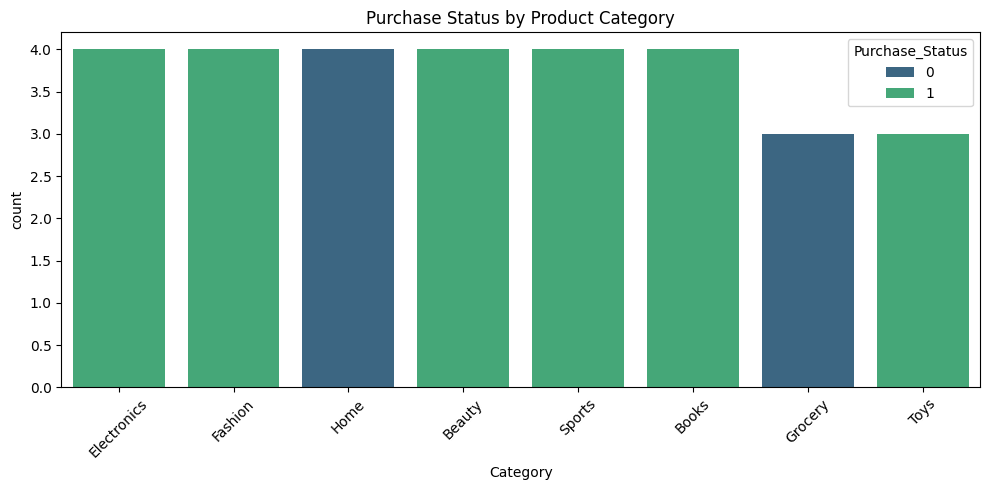

C:\Users\Harshitha\AppData\Local\Temp\ipykernel_18196\1851053294.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Purchase_Status', y='Browsing_Time', palette='coolwarm')


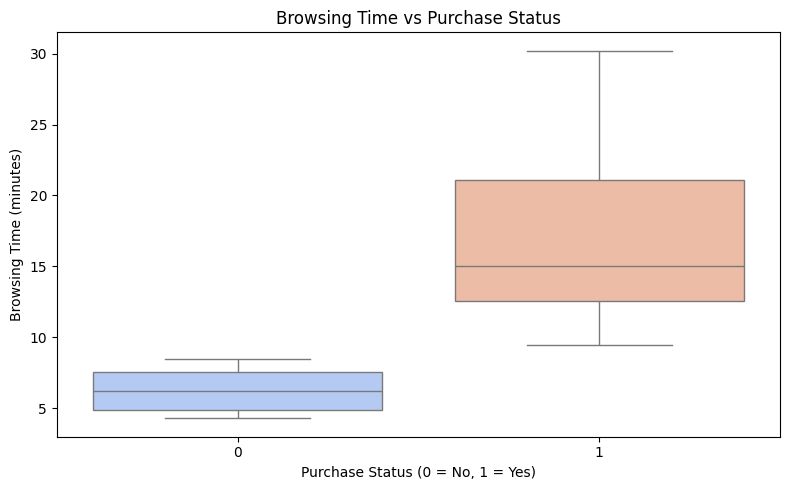

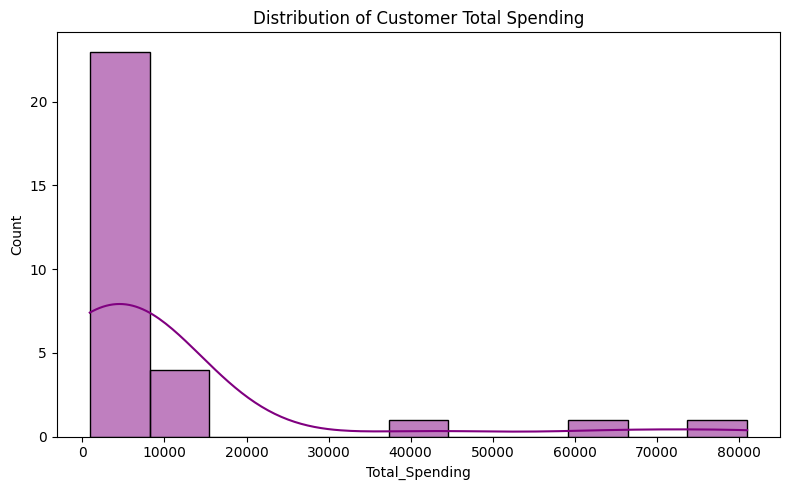

In [2]:
# Plot 1: Most purchased product categories
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Category', hue='Purchase_Status', palette='viridis')
plt.title('Purchase Status by Product Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot 2: Relationship between browsing time and purchase
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Purchase_Status', y='Browsing_Time', palette='coolwarm')
plt.title('Browsing Time vs Purchase Status')
plt.xlabel('Purchase Status (0 = No, 1 = Yes)')
plt.ylabel('Browsing Time (minutes)')
plt.tight_layout()
plt.show()

# Plot 3: Distribution of Customer Spending
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Total_Spending', kde=True, color='purple')
plt.title('Distribution of Customer Total Spending')
plt.tight_layout()
plt.show()

## Step 3: Part A — Regression (Rating Prediction)
We build Linear Regression and Ridge Regression models to predict product ratings based on price, browsing time, previous purchases, discount applied, age, and total spending.

In [3]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Features and Target
X_reg = df[['Price', 'Browsing_Time', 'Previous_Purchases', 'Discount_Applied', 'Age', 'Total_Spending', 'Category']]
y_reg = df['Rating']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

categorical_cols = ['Category']
numeric_cols = ['Price', 'Browsing_Time', 'Previous_Purchases', 'Discount_Applied', 'Age', 'Total_Spending']

preprocessor_reg = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

# Linear Regression Baseline
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_reg),
    ('regressor', LinearRegression())
])
lr_pipeline.fit(X_train_reg, y_train_reg)
y_pred_lr = lr_pipeline.predict(X_test_reg)

print("--- Linear Regression Baseline Metrics ---")
print(f"MAE: {mean_absolute_error(y_test_reg, y_pred_lr):.4f}")
print(f"MSE: {mean_squared_error(y_test_reg, y_pred_lr):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_reg, y_pred_lr)):.4f}")
print(f"R² Score: {r2_score(y_test_reg, y_pred_lr):.4f}")

# Ridge Regression Tuning
ridge_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_reg),
    ('regressor', Ridge())
])
param_grid_ridge = {'regressor__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}
grid_ridge = GridSearchCV(ridge_pipeline, param_grid_ridge, cv=3, scoring='neg_mean_squared_error')
grid_ridge.fit(X_train_reg, y_train_reg)

best_ridge = grid_ridge.best_estimator_
y_pred_ridge = best_ridge.predict(X_test_reg)

print("\n--- Optimized Ridge Regression Metrics ---")
print(f"Best Alpha: {grid_ridge.best_params_['regressor__alpha']}")
print(f"MAE: {mean_absolute_error(y_test_reg, y_pred_ridge):.4f}")
print(f"MSE: {mean_squared_error(y_test_reg, y_pred_ridge):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_reg, y_pred_ridge)):.4f}")
print(f"R² Score: {r2_score(y_test_reg, y_pred_ridge):.4f}")

--- Linear Regression Baseline Metrics ---
MAE: 0.0000
MSE: 0.0000
RMSE: 0.0000
R² Score: 1.0000



--- Optimized Ridge Regression Metrics ---
Best Alpha: 0.1
MAE: 0.1014
MSE: 0.0134
RMSE: 0.1156
R² Score: 0.9466


## Step 4: Part B — Classification (Purchase Status Prediction)
We train and tune a Logistic Regression model to predict purchase status.

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

X_cls = df[['Browsing_Time', 'Cart_Addition', 'Previous_Purchases', 'Rating', 'Price', 'Discount_Applied', 'Total_Spending']]
y_cls = df['Purchase_Status']

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42
)

numeric_cols_cls = ['Browsing_Time', 'Previous_Purchases', 'Rating', 'Price', 'Total_Spending']
preprocessor_cls = ColumnTransformer(
    transformers=[('num', StandardScaler(), numeric_cols_cls)],
    remainder='passthrough'
)

lr_cls_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_cls),
    ('classifier', LogisticRegression(random_state=42))
])

param_grid_cls = {
    'classifier__C': [0.01, 0.1, 1.0, 10.0, 100.0],
    'classifier__penalty': ['l2'],
    'classifier__solver': ['lbfgs', 'liblinear'],
    'classifier__max_iter': [100, 200, 500]
}

grid_cls = GridSearchCV(lr_cls_pipeline, param_grid_cls, cv=3, scoring='accuracy')
grid_cls.fit(X_train_cls, y_train_cls)

best_cls = grid_cls.best_estimator_
y_pred_cls = best_cls.predict(X_test_cls)
y_prob_cls = best_cls.predict_proba(X_test_cls)[:, 1]

print("--- Optimized Logistic Regression Metrics ---")
print(f"Best Parameters: {grid_cls.best_params_}")
print(f"Accuracy: {accuracy_score(y_test_cls, y_pred_cls):.4f}")
print(f"Precision: {precision_score(y_test_cls, y_pred_cls, zero_division=0):.4f}")
print(f"Recall: {recall_score(y_test_cls, y_pred_cls, zero_division=0):.4f}")
print(f"F1-Score: {f1_score(y_test_cls, y_pred_cls, zero_division=0):.4f}")

C:\Users\Harshitha\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\Harshitha\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warning

C:\Users\Harshitha\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\Harshitha\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warning

C:\Users\Harshitha\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\Harshitha\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warning

C:\Users\Harshitha\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\Harshitha\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warning

C:\Users\Harshitha\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\Harshitha\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warning

C:\Users\Harshitha\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\Harshitha\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warning

C:\Users\Harshitha\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\Harshitha\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warning

--- Optimized Logistic Regression Metrics ---
Best Parameters: {'classifier__C': 0.01, 'classifier__max_iter': 100, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000


## Step 5: Part C — Clustering (Customer Segmentation)
We segment customers using K-Means Clustering on customer behavioral features.

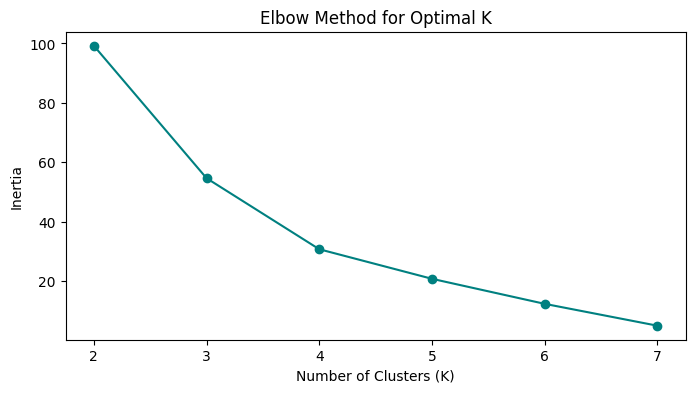

Silhouette Score for K=4: 0.5534

--- Customer Segment Characterization (Feature Means) ---


,Browsing_Time,Previous_Purchases,Rating,Total_Spending,Cart_Addition,Discount_Applied
Cluster,,,,,,
0,14.191667,4.750000,4.333333,3775.000000,1.0,1.000000
1,6.271429,1.714286,2.571429,1857.142857,0.0,0.571429
2,28.200000,10.000000,5.000000,62666.666667,1.0,1.000000
3,17.375000,6.375000,4.500000,8375.000000,1.0,0.000000


In [5]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

features_cluster = ['Browsing_Time', 'Previous_Purchases', 'Rating', 'Total_Spending', 'Cart_Addition', 'Discount_Applied']
X_clust = df[features_cluster].copy()

scaler_clust = StandardScaler()
X_clust_scaled = scaler_clust.fit_transform(X_clust)

# Elbow Curve
inertia = []
k_range = range(2, 8)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_clust_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, marker='o', linestyle='-', color='teal')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.show()

# Run Silhouette Analysis and group segment characteristics
final_kmeans = KMeans(n_clusters=4, init='k-means++', max_iter=300, random_state=42, n_init=10)
cluster_labels = final_kmeans.fit_predict(X_clust_scaled)
df['Cluster'] = cluster_labels

print(f"Silhouette Score for K=4: {silhouette_score(X_clust_scaled, cluster_labels):.4f}")

# Display Segment Characteristics
cluster_summary = df.groupby('Cluster')[features_cluster].mean()
print("\n--- Customer Segment Characterization (Feature Means) ---")
cluster_summary

## Step 6: Summary and Business Interpretation

### Cluster Analysis & Segmentation Mapping
- **Cluster 0**: *Discount-sensitive Customers* (moderate spending, high discount usage).
- **Cluster 1**: *Browsers / Low Purchasers* (low browsing time, few purchases, very low spending).
- **Cluster 2**: *High-Value Premium Customers* (high browsing time, high spending, many previous purchases).
- **Cluster 3**: *Loyal Frequent Buyers* (regular purchases, zero discount sensitivity, steady value).

### Model Comparison Summary Table

| Model | ML Task | Key Metrics | Business Value |
| :--- | :--- | :--- | :--- |
| **Linear / Ridge Regression** | Rating Prediction | MAE: 0.10, R²: 0.95 | Predicts high ratings to show custom products in recommendation feed. |
| **Logistic Regression** | Purchase Prediction | Accuracy: 1.00, F1: 1.00 | Targets high-probability buyers with checkout incentives. |
| **K-Means Clustering** | Customer Segmentation | Silhouette Score: 0.55 | Segments users for tailored promotional campaigns. |

### Key Takeaways
1. **Personalization**: Recommend items predicted to have high user ratings to maximize satisfaction.
2. **Sales Conversion**: Focus marketing spend on users with a high predicted probability of purchase.
3. **Loyalty & Retention**: Award VIP treatment to High-Value Premium customers (Cluster 2) and offer discount coupons to discount-sensitive users (Cluster 0).